In [ ]:
#Import packages
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
carAuction = pd.read_csv("/content/drive/MyDrive/IS670_data/car_kick.csv")
carAuction

,PurchDate,VehYear,VehicleAge,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,...,WheelTypeID,WheelType,Nationality,Size,TopThreeAmericanName,BYRNO,VNZIP1,VNST,IsOnlineSale,IsBadBuy
0,1289952000,2006,4,51954,6197,7062,9605,10426,5341,6351,...,2,Covers,AMERICAN,MEDIUM,CHRYSLER,99750,32124,FL,0,0
1,1242691200,2005,4,89127,3688,4783,4483,5666,3688,4783,...,2,Covers,AMERICAN,MEDIUM,FORD,20833,78754,TX,0,0
2,1248220800,2006,3,71271,6897,8449,7949,9625,6868,8549,...,1,Alloy,AMERICAN,LARGE,GM,22916,80011,CO,0,0
3,1285718400,2008,2,83338,7878,8925,11723,13026,7801,8704,...,2,Covers,AMERICAN,LARGE,GM,23657,94544,CA,0,0
4,1237334400,2007,2,58698,8800,10091,10004,11398,7355,8543,...,1,Alloy,AMERICAN,LARGE,GM,20833,77086,TX,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67206,1285804800,2008,2,56072,6255,6972,9852,10567,6326,7126,...,2,Covers,AMERICAN,MEDIUM,CHRYSLER,22808,77061,TX,0,1
67207,1274918400,2004,6,94232,8359,9645,12042,13302,7505,8188,...,1,Alloy,'TOP LINE ASIAN','MEDIUM SUV',OTHER,17675,28273,NC,0,1
67208,1280448000,2004,6,79534,2805,3826,6132,6871,3106,4479,...,1,Alloy,AMERICAN,MEDIUM,GM,18880,37771,TN,0,1
67209,1285200000,2003,7,79394,4042,5296,7335,8983,3534,4732,...,2,Covers,AMERICAN,'MEDIUM SUV',GM,23657,92337,CA,0,1


###1. Business Understanding

The business context is that auto dealerships would often be pruchasing used cars from an auto auction in order to sell them at a profit in thier dealerships. The problem is that these cars could have potential problems that the dealerships can't visualize during the buying process. These problematic cars are known as "kicked" cars, in which they have problems that would make them more costly to fix rather than gaining a profit for those dealerships.

We can frame the problem as a binary classification task by identifying two outcomes within the model that would need to be created. Those outcomes would either be "Yes", meaning the car is a kick car, or "No" meaning the car is not kicked and is safe to buy. The model would address the problem by helping dealerships identify if a car is safe to buy or not through any identifyable patterns.

###2. Data Understanding

In order to identify what variables that would need to be defined, we would need to know those variables and their types through this code:

In [ ]:
carAuction.dtypes

,0
PurchDate,int64
VehYear,int64
VehicleAge,int64
VehOdo,int64
MMRAcquisitionAuctionAveragePrice,int64
MMRAcquisitionAuctionCleanPrice,int64
MMRAcquisitionRetailAveragePrice,int64
MMRAcquisitonRetailCleanPrice,int64
MMRCurrentAuctionAveragePrice,int64
MMRCurrentAuctionCleanPrice,int64


PurchDate- the date that the vehilce was purchased <br>
VehYear- the year the manufacturer made the vehicle <br>
VehicleAge- how old the vehicle is <br>
VehOdo- the mileage that the vehicle has <br>
MMRAcquisitionAuctionAveragePrice- Acquisition price for this vehicle in average condition as of current day <br>
MMRAcquisitionAuctionCleanPrice- aquisition price for a vehicle in clean condition <br>
MMRAcquisitionRetailAveragePrice- the average retail price of the vehicle at the time of purchase <br>
MMRAcquisitonRetailCleanPrice- the retail price of the vehicle in clean condition	<br>
MMRCurrentAuctionAveragePrice- the current auction price of the vehicle in average conditon <br>
MMRCurrentAuctionCleanPrice- current auction price of the vehicle in clean condition <br>
MMRCurrentRetailAveragePrice- the current retail average of the vehicle in average condition <br>
MMRCurrentRetailCleanPrice- the current retail price of the vehicle in clean coniditon <br>
VehBCost- Acquisition cost paid for the vehicle at time of purchase <br>
WarrantyCost- Warranty price <br>
Auction- Auction provider at which the vehicle was purchased <br>
Make- The manufacturer that made the vehicle <br>
Model- The model of the vehicle that the manufacturer made <br>
Trim- Trim level of the vehicle <br>
SubModel- More specific classification of the model <br>
Color- the color of the model <br>
Transmission- The vehicles transmission type <br>
WheelTypeID- The vehicle wheel type specific identification <br>
WheelType- The vehicle wheel type description <br>
Nationality- The region of origin of the manufacturers <br>
Size- The overall size of the vehicle <br>
TopThreeAmericanName- Identifies if the vehicle is part of the top three American manufacturers <br>
BYRNO- the unique identifier number of the buyer who purchased the vehicle <br>
VNZIP1- The zip code of where the vehicle was purchased <br>
VNST- the state where the vehicle was purchased <br>
IsOnlineSale- determines if the vehicle was purchased through an online auction <br>
IsBadBuy- determines whether the vehicle is a bad buy or not

Now with the variable definitions in mind, they would give an interpretation on how they relate to the problem in hand <br>

The vehicleAge, vehYear, and vehOdo would tell the dealership about the general usage of the car from when it was made to it's milage.<br>

The general information about the vehicle itself, being the make, model, trim, nationality, and transmission gives the dealership an idea of what to expect out a certain car as each car and manufacturer has its own reputation of being generally relaible or not. <br>

The MMR cost variables would represent the value of the car in different conditions and in different environments as it could show similarities and major differences if there are any. This is so the buyer can view if they are getting ripped off or are getting a fair deal when purchasing. <br>

The purchase environments themselves, being auciton, onlinesale, auction, and vnstate/zip, could tell if there is a pattern of the vehicle being lesser value, or being a bad buy from certain locations. It could also show if a certain locaiton generally have safer cars to buy in terms of their conditions since different areas would use their cars differently. <br>

The warrantycost of a vehicle could also relate the the problem as a higher price means that that car is known the be mechanically unreliable, possibly increasing the chance of it being a kicked car.

In [ ]:
# Write Confusion matrix, and stats (mean,median, mode) for each variable

In [ ]:
# Change the following categorical variables to "category"
carAuction['Auction'] = carAuction['Auction'].astype('category')
carAuction['Color'] = carAuction['Color'].astype('category')
carAuction['IsBadBuy'] = carAuction['IsBadBuy'].astype('category')
carAuction['Size'] = carAuction['Size'].astype('category')
carAuction['TopThreeAmericanName'] = carAuction['TopThreeAmericanName'].astype('category')
carAuction['WheelType'] = carAuction['WheelType'].astype('category')
carAuction['Transmission'] = carAuction['Transmission'].astype('category')
carAuction['Nationality'] = carAuction['Nationality'].astype('category')

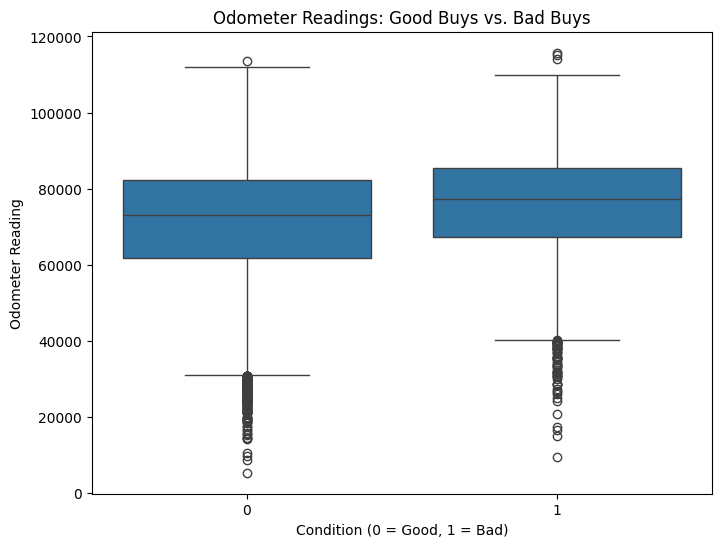

In [ ]:
# Boxplot comparing continuous mileage against the categorical IsBadBuy
plt.figure(figsize=(8, 6))

sns.boxplot(data=carAuction, x='IsBadBuy', y='VehOdo')

plt.title('Odometer Readings: Good Buys vs. Bad Buys')
plt.xlabel('Condition (0 = Good, 1 = Bad)')
plt.ylabel('Odometer Reading')

plt.show()

The vehicle mileage (VehOdo) is a standard on how much the car has been used, and you don't even have to be in analytics to know that much. The boxplot is used here in order to see if the average mileage of a bad buy is higher than that of a good buy. With these results, we can see that the average milage is slightly higher, meaning that vehicles tend to be a bit more of a bad buy if it has higher miles.

Text(0.5, 1.0, 'Scatterplot of VehBCost and VehOdo')

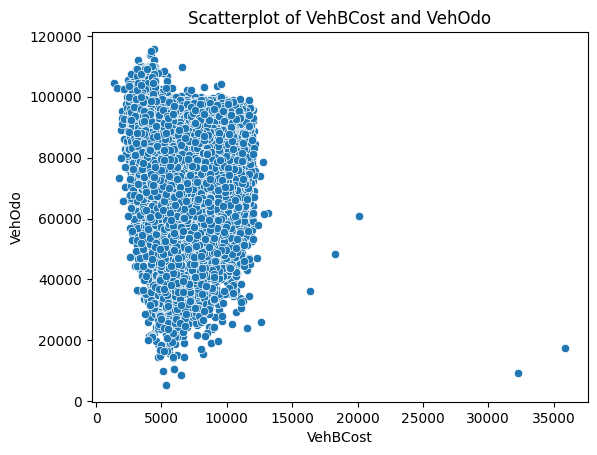

In [ ]:
# Scatterplot of VehBCost and VehOdo
snsplot = sns.scatterplot(x='VehBCost', y= 'VehOdo', data=carAuction)
snsplot.set_title("Scatterplot of VehBCost and VehOdo")

Now knowing that a higher mileage could lead to a bad buy, we could then view if there is any relation to pricing. With this, a buyer could save money making more informed purchases towards cars on the lower end of miles. From the results, most cars would be under $15,000 dollars, and then the few outliers that are more. A buyer could look at the lower left of the scatter plot to see which cars are the least expensive while also having low miles. Though to be sure of this, we would look at the next chart.

(0.0, 50000.0)

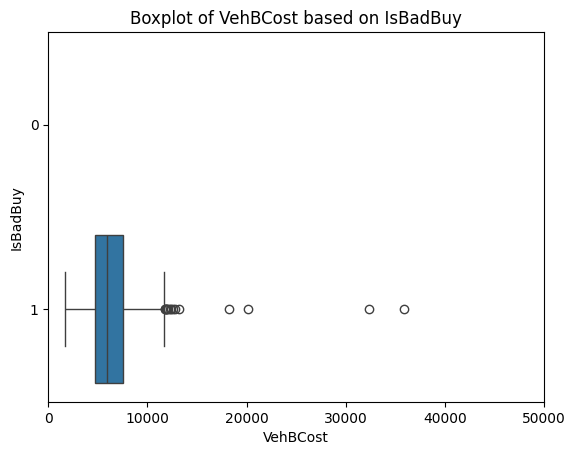

In [ ]:
snsplot = sns.boxplot(x='VehBCost', y= 'IsBadBuy', data = carAuction[carAuction['IsBadBuy']== 1])
snsplot.set_title("Boxplot of VehBCost based on IsBadBuy")
snsplot.set_xlim([0, 50000])

On the same topic of cost, this boxplot would analyze the average of 'IsBadBuy' with the vehicle cost. It would answer the concern made from the previous chart if buying cheaper with lower miles is worth it. As we can see, the bad buys would appear more often on the lower end of cost, making it not such a smart move to always invest in cheaper cars. It would appear that the more costly the car is, the lower the chance of it being a bad buy, even if the miles are a bit higher.

Text(0.5, 1.0, 'Scatterplot of VehOdo and WarrantyCost')

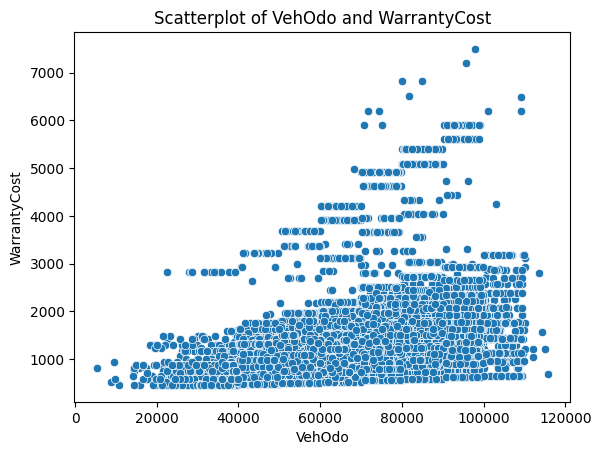

In [ ]:
# Scatterplot of VehOdo and WarrantyCost
snsplot = sns.scatterplot(x='VehOdo', y= 'WarrantyCost', data=carAuction)
snsplot.set_title("Scatterplot of VehOdo and WarrantyCost")

With this scatterplot, we would be able to view the correlation between the mileage of a vehicle and it's warranty cost. It is commonly known that vehicles would tend to have more expensive warranties if they break down more easily. By analyzing warranty cost with the mileage, the buyer could percept what could be a better buy through lower warranty costs and based on how much the car was used.

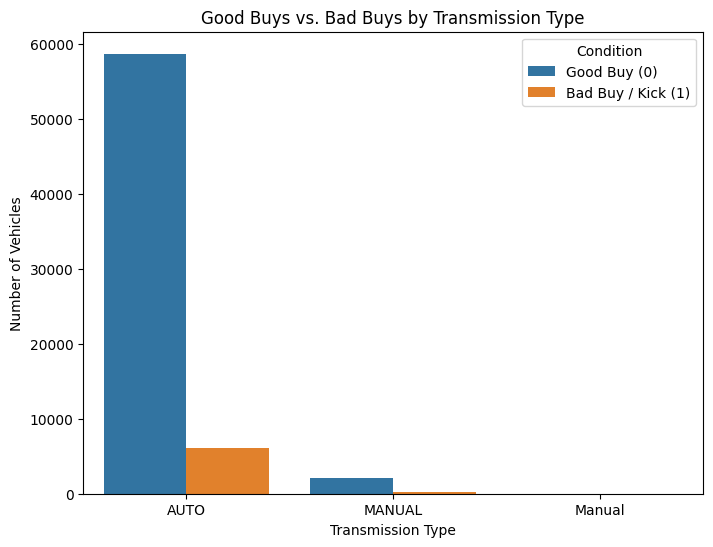

In [ ]:
#count plot grouped by Transmission and split by IsBadBuy
plt.figure(figsize=(8, 6))

sns.countplot(data=carAuction, x='Transmission', hue='IsBadBuy')

plt.title('Good Buys vs. Bad Buys by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Number of Vehicles')

plt.legend(title='Condition', labels=['Good Buy (0)', 'Bad Buy / Kick (1)'])

plt.show()

Switching gears, a buyer would look at the transmission types to view how many cars are a bad buy based on if they're a manual or automatic. From a mechanical point of view, cars would generally be more reliable if they are a manual rather than an automatic due to many electronical factors being added into automatics. In this case, the dataset focuses more on automatic transmissioned cars, and while most of them appear to be a good buy, there a quite a bit of them that got marked as a bad buy. In comparison to the manual transmission, barely any of the manuals are a bad buy. With that, a buyer could play it safe and purchase a manual car for a good buy.

(0.0, 7000.0)

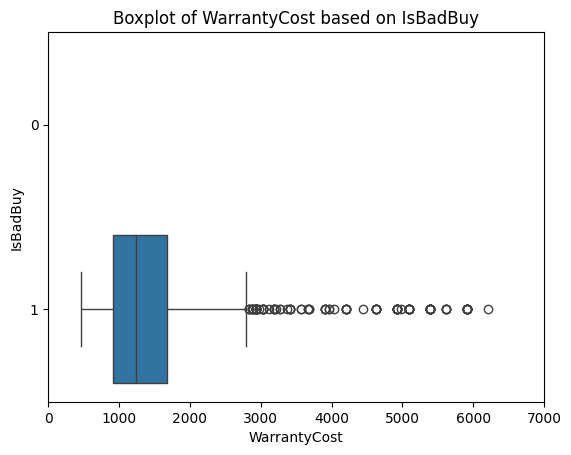

In [ ]:
# Boxplot of WarrantyCost based on IsBadBuy
snsplot = sns.boxplot(x='WarrantyCost', y= 'IsBadBuy', data = carAuction[carAuction['IsBadBuy']== 1])
snsplot.set_title("Boxplot of WarrantyCost based on IsBadBuy")
snsplot.set_xlim([0, 7000])

Now going off of the previous chart, the buyer can further analyze warranty cost with the vehicle being a bad buy. What we can gain from this analysis is that the average warranty cost would be around 1,000 dollars, with the maximum being just under 3,000 dollars. Of course, there are a few outliers that would show that the vehicle is a bad buy, but for the most part it would be between 500 dollars to 3,000 dollars. The buyer could stay away from this range in order to further reduce their chance of buying a bad car.

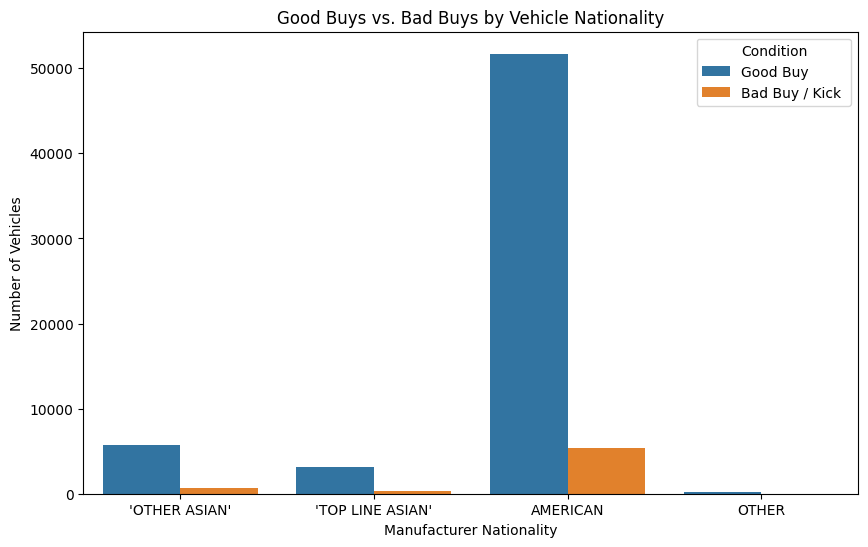

In [ ]:
#Good Buys vs. Bad Buys by Vehicle Nationality
plt.figure(figsize=(10, 6))

sns.countplot(data=carAuction, x='Nationality', hue='IsBadBuy')

plt.title('Good Buys vs. Bad Buys by Vehicle Nationality')
plt.xlabel('Manufacturer Nationality')
plt.ylabel('Number of Vehicles')

plt.legend(title='Condition', labels=['Good Buy', 'Bad Buy / Kick '])

plt.show()

Since cars are made from different manufacterers from different parts of the world, certain nationalities comes with a reputation that proceeds them. For instance, it is common knowledge that a car company from Asia (we could say Toyota or Lexus for example) would tend to be more reliable than one from America (Ford or Chevrolet). This chart would further prove that point as the Asian cars would have a better ratio of good buys vs bad buys in comparison to the Americans. A buyer could be more inclined to buy asian cars if they can instead of American, even though the data shows that are a lot more American cars. We could also view that the 'other' category has barely any bad buys, so the buyer could consider other nationalities as well.

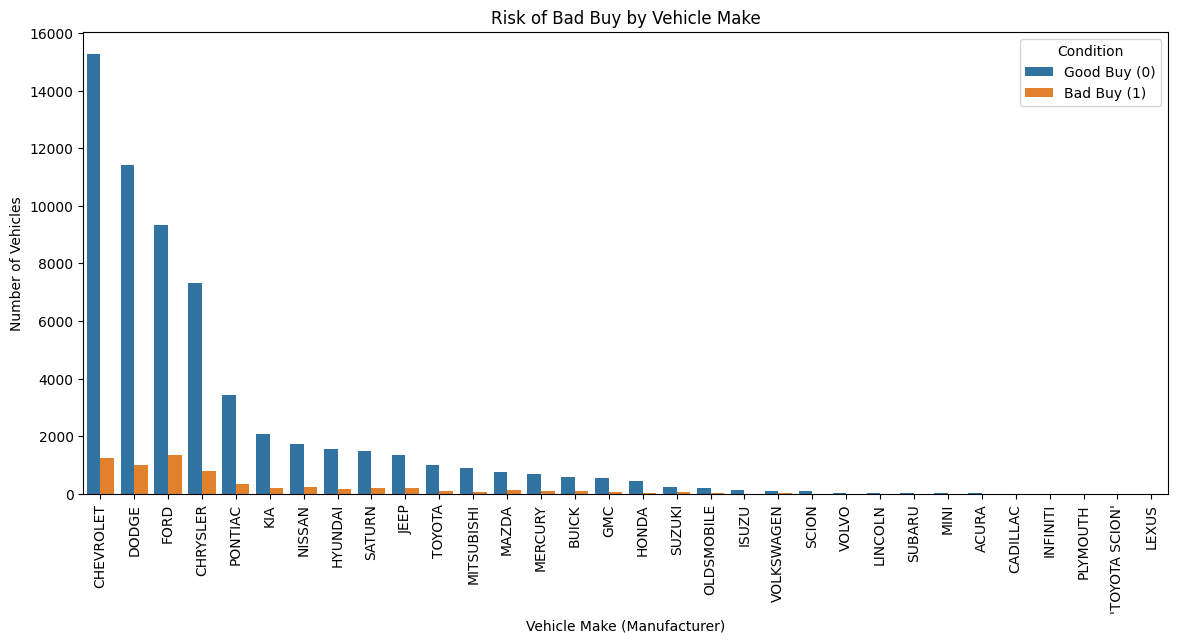

In [ ]:
# Bar chart with Make vs IsBadBuy
plt.figure(figsize=(14, 6))

# Group by Make, sorted by the most popular brands at the auction
sns.countplot(data=carAuction, x='Make', hue='IsBadBuy',
              order=carAuction['Make'].value_counts().index)

plt.title('Risk of Bad Buy by Vehicle Make')
plt.xlabel('Vehicle Make (Manufacturer)')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=90)
plt.legend(title='Condition', labels=['Good Buy (0)', 'Bad Buy (1)'])

plt.show()

Going off the previous chart from the nationalities, the buyer can further analyze each manufacturer to see which brands would have more good buys over the others. From this chart, the American brands would have the most cars that are bad buys over the asian brands, thus further supporting the previous chart as well. Just from this visual, Toyota and Kia would seem to have a better ratio of having good cars while Chevrolet and Ford would have more of a chance to get a bad buy.

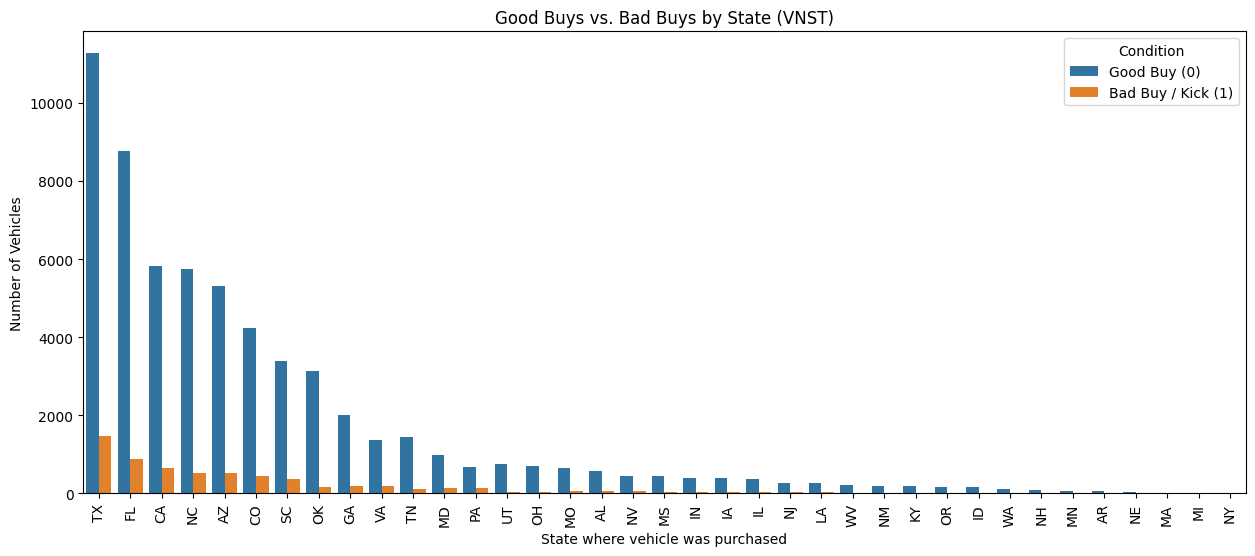

In [ ]:
# count plot grouped by VNST and split by IsBadBuy
plt.figure(figsize=(15, 6))

sns.countplot(data=carAuction, x='VNST', hue='IsBadBuy',
              order=carAuction['VNST'].value_counts().index)

plt.title('Good Buys vs. Bad Buys by State (VNST)')
plt.xlabel('State where vehicle was purchased')
plt.ylabel('Number of Vehicles')

plt.legend(title='Condition', labels=['Good Buy (0)', 'Bad Buy / Kick (1)'])

plt.xticks(rotation=90)

plt.show()

This chart would analyze the states of the vehicle and if they are a bad buy. Different states would tend to have different environments in terms of weather and road terrains. Through this chart, most cars would be from Texas, which would also have the most amount of bad buys within them compared to the other states. The buyer could look at the states from where the cars are coming from and would be aware that Texas has the highest chance of getting a bad car, along with Florida, California, North Carolina, and Arizona.

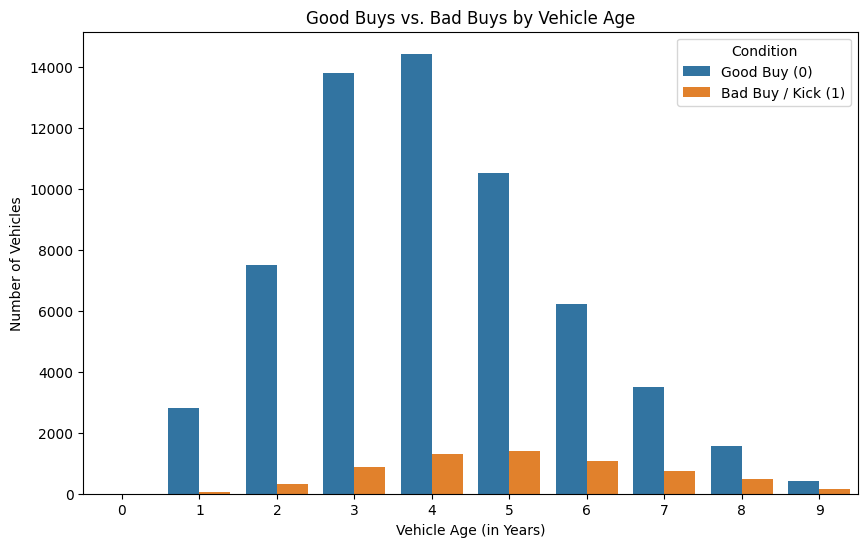

In [ ]:
# Count plot grouped by VehicleAge and split by IsBadBuy
plt.figure(figsize=(10, 6))


sns.countplot(data=carAuction, x='VehicleAge', hue='IsBadBuy')

plt.title('Good Buys vs. Bad Buys by Vehicle Age')
plt.xlabel('Vehicle Age (in Years)')
plt.ylabel('Number of Vehicles')

plt.legend(title='Condition', labels=['Good Buy (0)', 'Bad Buy / Kick (1)'])

plt.show()

Through this chart, the buyer would be able to see the correlation with vehicle age and if its a bad buy. Most vehicles would be 3 - 5 years old, in which they would have the most amount of good buys. One thing to keep in mind though is that the vehicles with the most bad buys would be aged 4 and 5 years old, to which a buyer should be aware when purchasing a vehicle. To be on the safer side, a buyer could purchase a vehicle thats below 3 years old or purchase a vehicle that's over 9 years old as they would show to have the least amount of bad buys. This would also make sense in general logic as a newer car tends to have fewer issues in terms of its mechanical functions.

The target variable in this dataset would be 'IsBadBuy'. It is a categorical type and It is also binary as it only has a value of 0 (the vehicle being a good buy) and 1 (the vehicle being a bad buy).

Yes, I do believe that other existing variables in the dataset can help build a meaningful predictive model, though that isn't to say that all of the variables are helpful. As shown from the previously explained charts, some variables are useful when it comes to helping whether a car is a bad buy or not. While on the other hand, there are variables that aren't as helpful and may come off as redundant information, depending on the context that they are used of course. <br>

One example could be with VehYear and VehicleAge. If it is known that the car was made in 2000 and was bought in 2005, then we would already know that it is 5 years old, making VehicleAge the only viable one to keep. So no, we cannot use all of the variables as predictors.

###3. Data Preparation

Some of the variable types have already been converted previously in the data understanding section, though no further variables would need to be converted for now as they wouldn't be relevant in determining whether a vehicle is a bad buy or not.

To view if there are any missing values within the variables, we must use the following code:

In [ ]:
carAuction.isnull().sum()

,0
PurchDate,0
VehYear,0
VehicleAge,0
VehOdo,0
MMRAcquisitionAuctionAveragePrice,0
MMRAcquisitionAuctionCleanPrice,0
MMRAcquisitionRetailAveragePrice,0
MMRAcquisitonRetailCleanPrice,0
MMRCurrentAuctionAveragePrice,0
MMRCurrentAuctionCleanPrice,0


From this chart, we could see that none of the variables would contain missing values to fill in.

Correlated Variables would mean that some variables would give the same information when creating a model. This is also known as multicollinearity. Within this dataset, most of the MMR price variables would lead to redundant information as they would move up and down simultaneously, making it more complex for little to no benefit. In addition, Vehicle Year would be redundant as well since the information would be similar to Vehicle Age. <br>

To solve this, we must remove the aforementioned variables through this code:

In [ ]:
columns_to_drop = [
    'VehYear', # Redundant with VehicleAge
    'WheelTypeID', # Redundant with the text column WheelType
]

mmr_to_drop = [
    'MMRAcquisitionAuctionCleanPrice',
    'MMRAcquisitionRetailAveragePrice',
    'MMRAcquisitonRetailCleanPrice',
    'MMRCurrentAuctionAveragePrice',
    'MMRCurrentAuctionCleanPrice',
    'MMRCurrentRetailAveragePrice',
    'MMRCurrentRetailCleanPrice'
]
# 'MMRAcquisitionAuctionAveragePrice' is the only one remaining

carAuction = carAuction.drop(columns=columns_to_drop + mmr_to_drop)

The MMR Acquisition Auction Average Price was kept within this dataset as it would represent the only relevant information that the buyer would need, since they are purchasing the vehicle and need to keep track of that price. In comparison to MMR Price variables with 'Current', they would only represent the price of the vehicle at a future time when it's valued, making it not useful when identifying vehicles in the present/past time, thus solving the possible **data leakage** issue. <BR>

When removing MMR Prices with 'Retail', it would remove irrelevant information to the buyer. All of the vehicles within the dataset are being bought through an auction, not retail off of another dealership. <br>

Finally, when removing the 'Clean' MMR Prices, that would also remove irrelevant information from the dataset. We can say that all of the cars from the auction have to have some form of wear and tear, whether it's mechanical or visually, or else it wouldn't be there in the first place. The 'Clean' variables would represent cars that are in pristine, out of the factory line condition, to which seems considering the environment of an auction in the first place.

To view if the data itself is balanced within the target variable, the following code would need to be ran:

In [ ]:
print(carAuction['IsBadBuy'].value_counts())

print("\nPercentage breakdown:")
print(carAuction['IsBadBuy'].value_counts(normalize=True) * 100)

IsBadBuy
0    60795
1     6416
Name: count, dtype: int64

Percentage breakdown:
IsBadBuy
0    90.453944
1     9.546056
Name: proportion, dtype: float64


From the code, we could see that the data is not balanced because there is significantly more cars that are considered a good buy rather than a bad buy. While this might seem like a good thing a first, it would end up hurting the model we could create since it could lead to inaccuracy of what cars are actually bad buys. <br>

In order to fix this, an analyst could either undersample, which includes removing random rows of good buys until it would match the amount of bad buys, or could oversample, to which more bad buy rows are created to match the amount of good buys there are.

In order to create dummy coding for the categorical variables, the following code must be ran:

In [ ]:
categorical_cols = carAuction.select_dtypes(include=['object', 'category']).columns.tolist()

# This removes the target variable 'IsBadBuy' so it doesn't get affected
if 'IsBadBuy' in categorical_cols:
    categorical_cols.remove('IsBadBuy')

carAuction = pd.get_dummies(carAuction, columns=categorical_cols, drop_first=True)

Using this code, we would be able to dummy code the categorical variables except the 'IsBadBuy' target variable as it is already defined in 0 and 1's. The point of dummy coding would due to the fact that machine learning models would not be able to analyze text, thus creating multiple errors. In making the variables numerical, it would set us up for the modeling section of the process!

###4. Modeling

Now we begin our modeling. First, we must find what are actually the most important variables when it comes to determining what makes a car a good or a bad buy. We can do that be entering the code below:

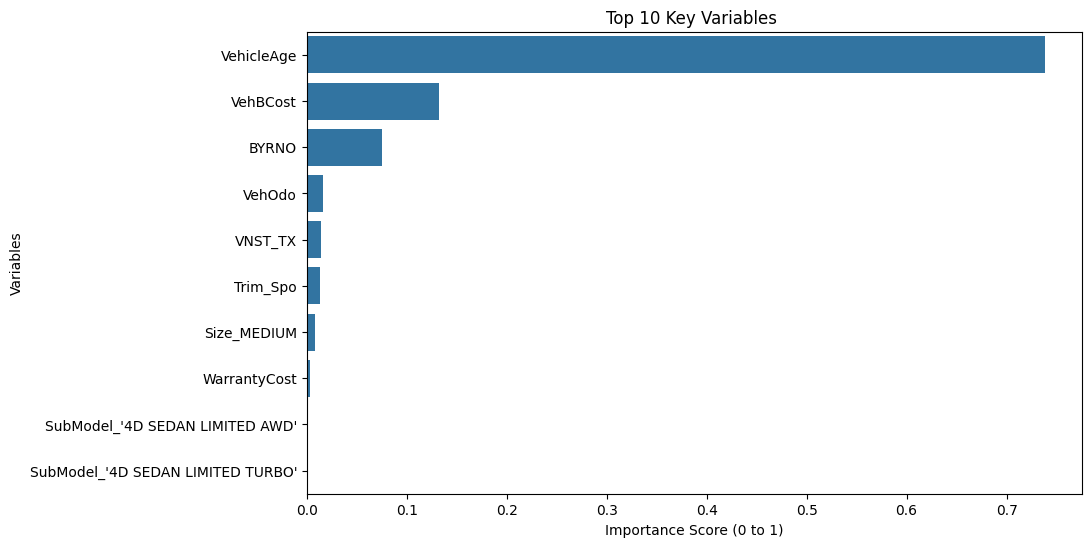

In [ ]:
# Separate the features (X) from the target variable (y)
X = carAuction.drop('IsBadBuy', axis=1)
y = carAuction['IsBadBuy']

# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dt_model = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

# We extract and plot the top 10 most important variables
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
top_10_importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_importances.values, y=top_10_importances.index)
plt.title('Top 10 Key Variables ')
plt.xlabel('Importance Score (0 to 1)')
plt.ylabel('Variables')
plt.show()

Now that we identified Vehicle Age being the most important variable, it will rely more on that to split the cars up as good or bad buys. Now we can create our first decision tree using the training data below:

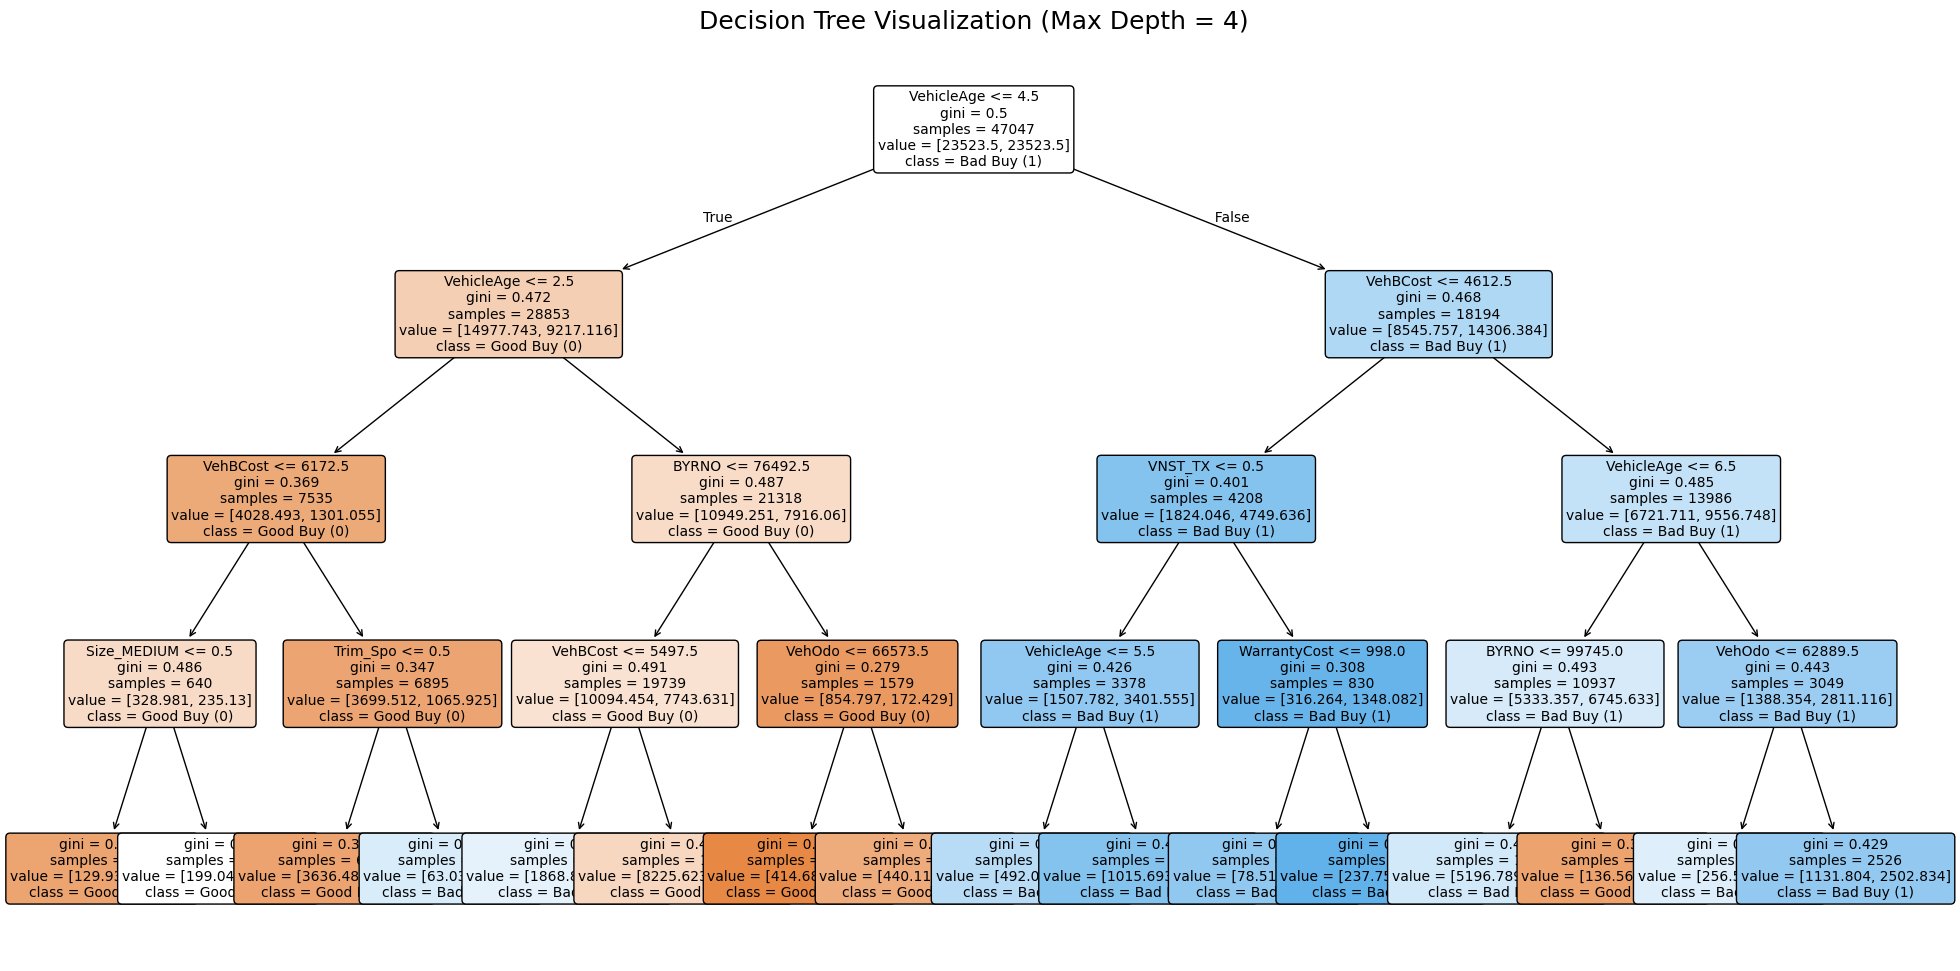

In [ ]:
# Set a very large figure size so the boxes don't overlap
plt.figure(figsize=(24, 12))

# Plot the trained Decision Tree
tree.plot_tree(dt_model,
               feature_names=X.columns,
               class_names=['Good Buy (0)', 'Bad Buy (1)'],
               filled=True,      # Colors the boxes
               rounded=True,     # Rounds the corners of the boxes
               fontsize=10)

plt.title('Decision Tree Visualization (Max Depth = 4)', fontsize=18)
plt.show()

Now that a decision tree is made, we can create a confusion matrix to identify how many cars are a good buy and a bad buy, according to the training data:

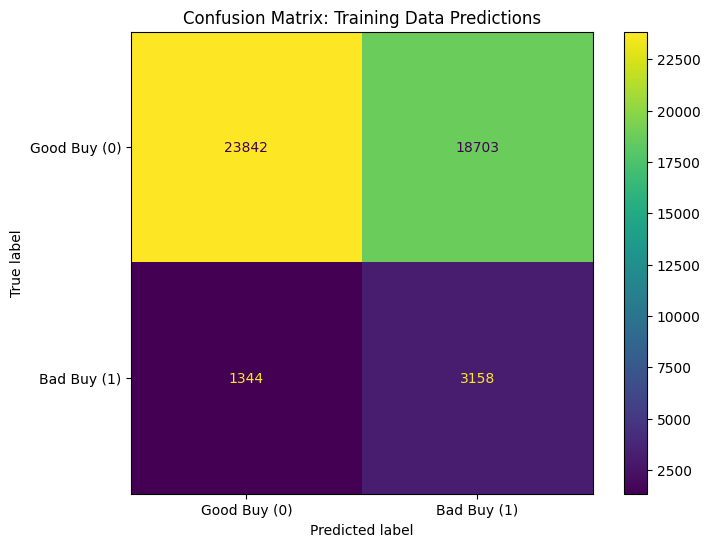

In [ ]:
# training model used to make predictions
y_train_pred = dt_model.predict(X_train)

# Generate the confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)

# Visually plot the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                              display_labels=['Good Buy (0)', 'Bad Buy (1)'])

disp.plot(values_format='d', ax=plt.gca())

plt.title('Confusion Matrix: Training Data Predictions')
plt.show()

The top left, being true negatives, would identify the correctly predicted cars that that were good cars. The top right identifes the bad buys that were actually good buys (False Positives). The bottom left identifies cars that were identified as good buys, but were bad buys in reality (False Negatives). Finally, the bottom right correctly identifies the bad buys (True Positives). Ideally, a buyer would want to stay away from the bottom left cars since they could mean a total loss in their buying money from buying these bad cars. <br>


Now onto the classification report of this model:

In [ ]:
# Print the classification report for the training data
print("Classification Report: Training Data Predictions\n")
print(classification_report(y_train, y_train_pred, target_names=['Good Buy (0)', 'Bad Buy (1)']))

Classification Report: Training Data Predictions

              precision    recall  f1-score   support

Good Buy (0)       0.95      0.56      0.70     42545
 Bad Buy (1)       0.14      0.70      0.24      4502

    accuracy                           0.57     47047
   macro avg       0.55      0.63      0.47     47047
weighted avg       0.87      0.57      0.66     47047



From the classification report, we can see that that it has an overall accuracy of 90%, though that wouldn't determine everything about the model. The precision metric would demonstrate how often correct the model is when predicting a bad buy, being 88%. The recall would predict how much of the actual good buys were identified within the model.

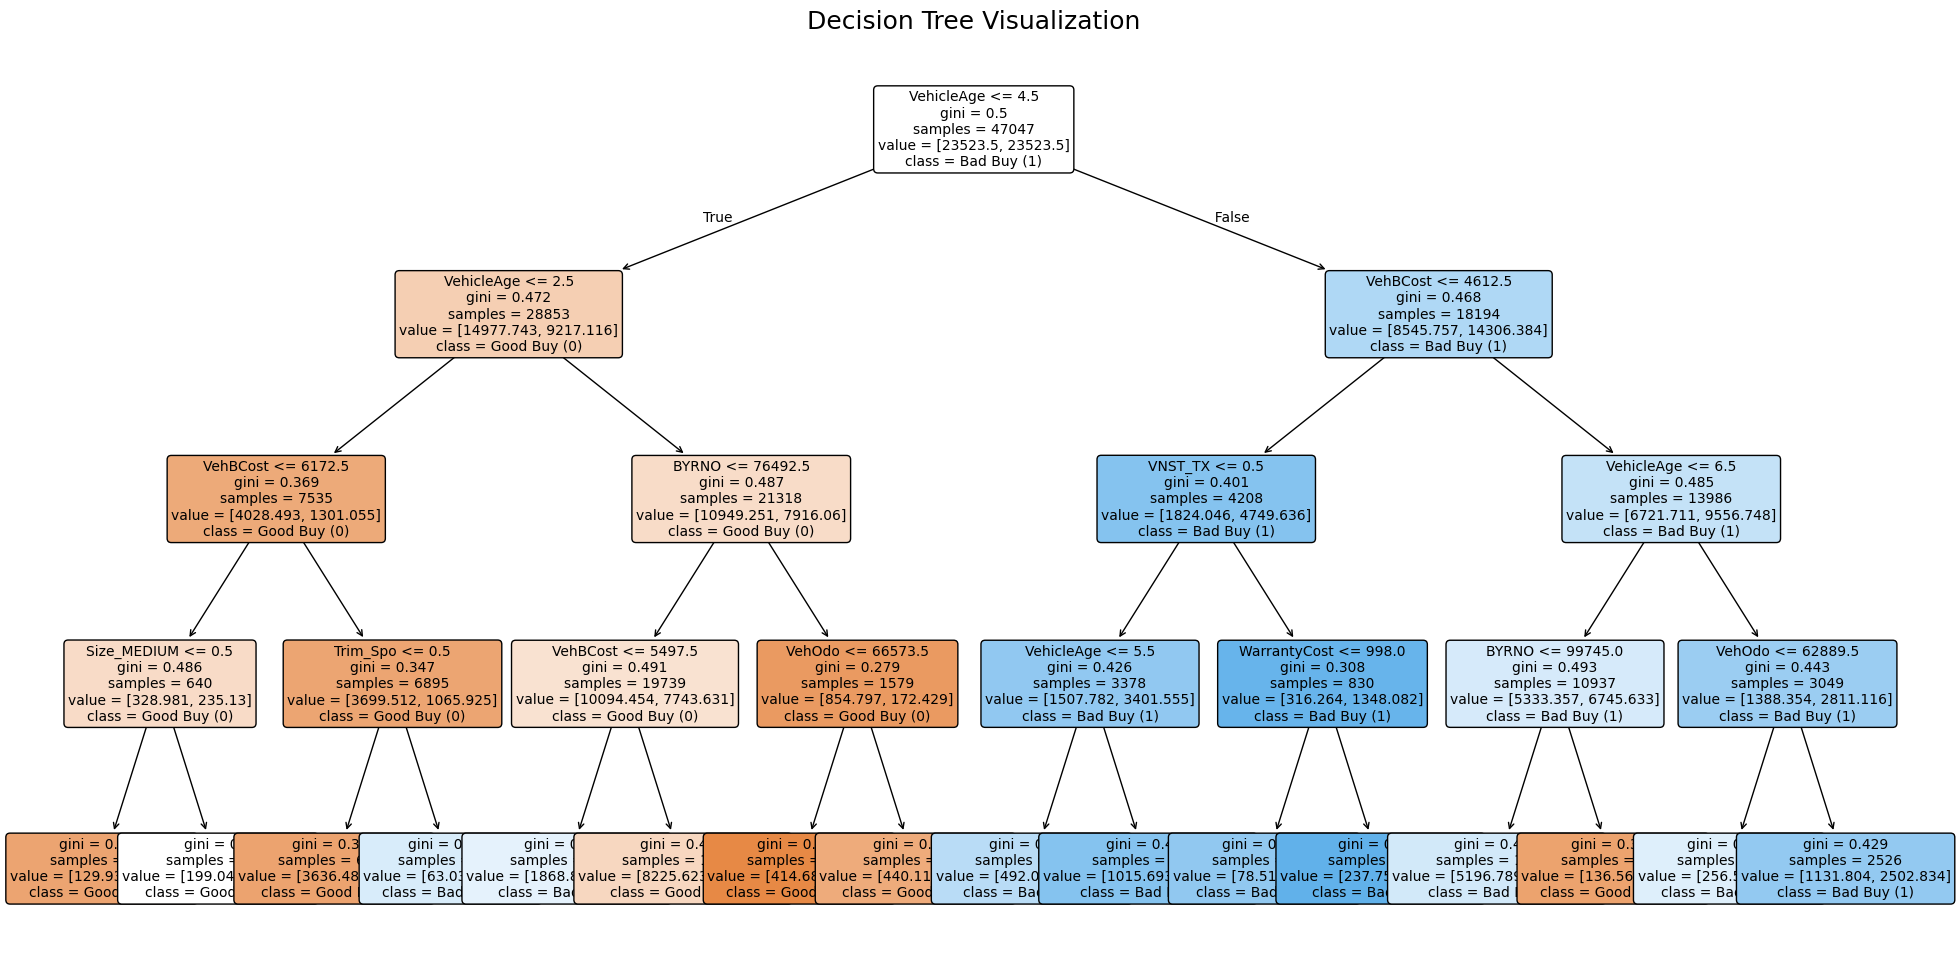

In [ ]:
# Set a very large figure size so the boxes don't overlap
plt.figure(figsize=(24, 12))

# Plot the trained Decision Tree
tree.plot_tree(dt_model,
               feature_names=X.columns,
               class_names=['Good Buy (0)', 'Bad Buy (1)'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.title('Decision Tree Visualization', fontsize=18)
plt.show()

Moving on to the testing data, we can view if there are major differences within the testing and training data.

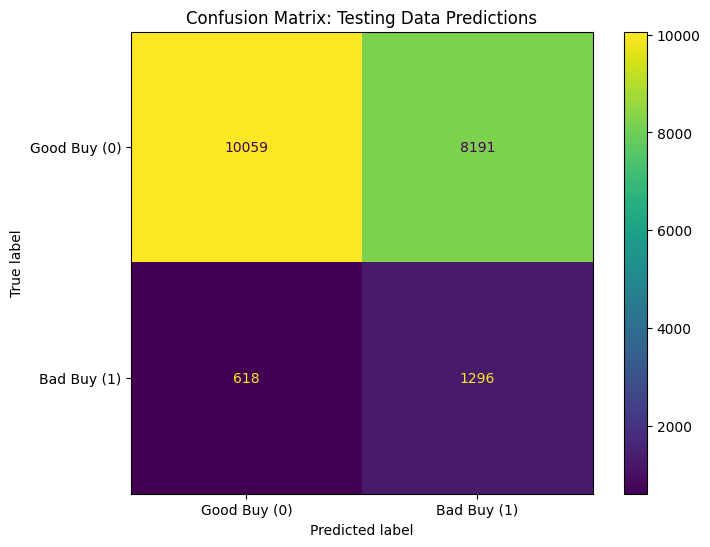

In [ ]:
# Predictions with testing data
y_test_pred = dt_model.predict(X_test)


cm_test = confusion_matrix(y_test, y_test_pred)


plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                              display_labels=['Good Buy (0)', 'Bad Buy (1)'])

disp.plot(values_format='d', ax=plt.gca())

plt.title('Confusion Matrix: Testing Data Predictions')
plt.show()

In [ ]:
print("\nClassification Report: Testing Data Predictions\n")
print(classification_report(y_test, y_test_pred, target_names=['Good Buy (0)', 'Bad Buy (1)']))


Classification Report: Testing Data Predictions

              precision    recall  f1-score   support

Good Buy (0)       0.94      0.55      0.70     18250
 Bad Buy (1)       0.14      0.68      0.23      1914

    accuracy                           0.56     20164
   macro avg       0.54      0.61      0.46     20164
weighted avg       0.87      0.56      0.65     20164



The testing data would achieve similar results to the training data, no suprise there. Though with this we have a good idea of what the model can describe with its current max depth. Next, we can analyze the best possible max depth and AUC (Area Under Curve) that the model can achieve with the following code:

In [ ]:

best_auc = 0
best_config = None


# Loop two criteria
for criterion in ["gini", "entropy"]:

    # Loop through maximum depths from 2 to 15
    for depth in range(2, 15):

        model = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)

        # Train the model on the training data
        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]

        # Calculate the AUC score
        auc = roc_auc_score(y_test, y_prob)

        # Check if this new AUC is the highest one we've seen so far!
        if auc > best_auc:
            best_auc = auc
            best_config = (criterion, depth)


print(f"Highest AUC Score: {best_auc:.4f}")
print(f"Best Configuration (Criterion, Max Depth): {best_config}")

Highest AUC Score: 0.6526
Best Configuration (Criterion, Max Depth): ('gini', 6)


**(Best Model Below)**

With a new, preferrable max depth, we can re-run the model to test if there is any difference when changing it.

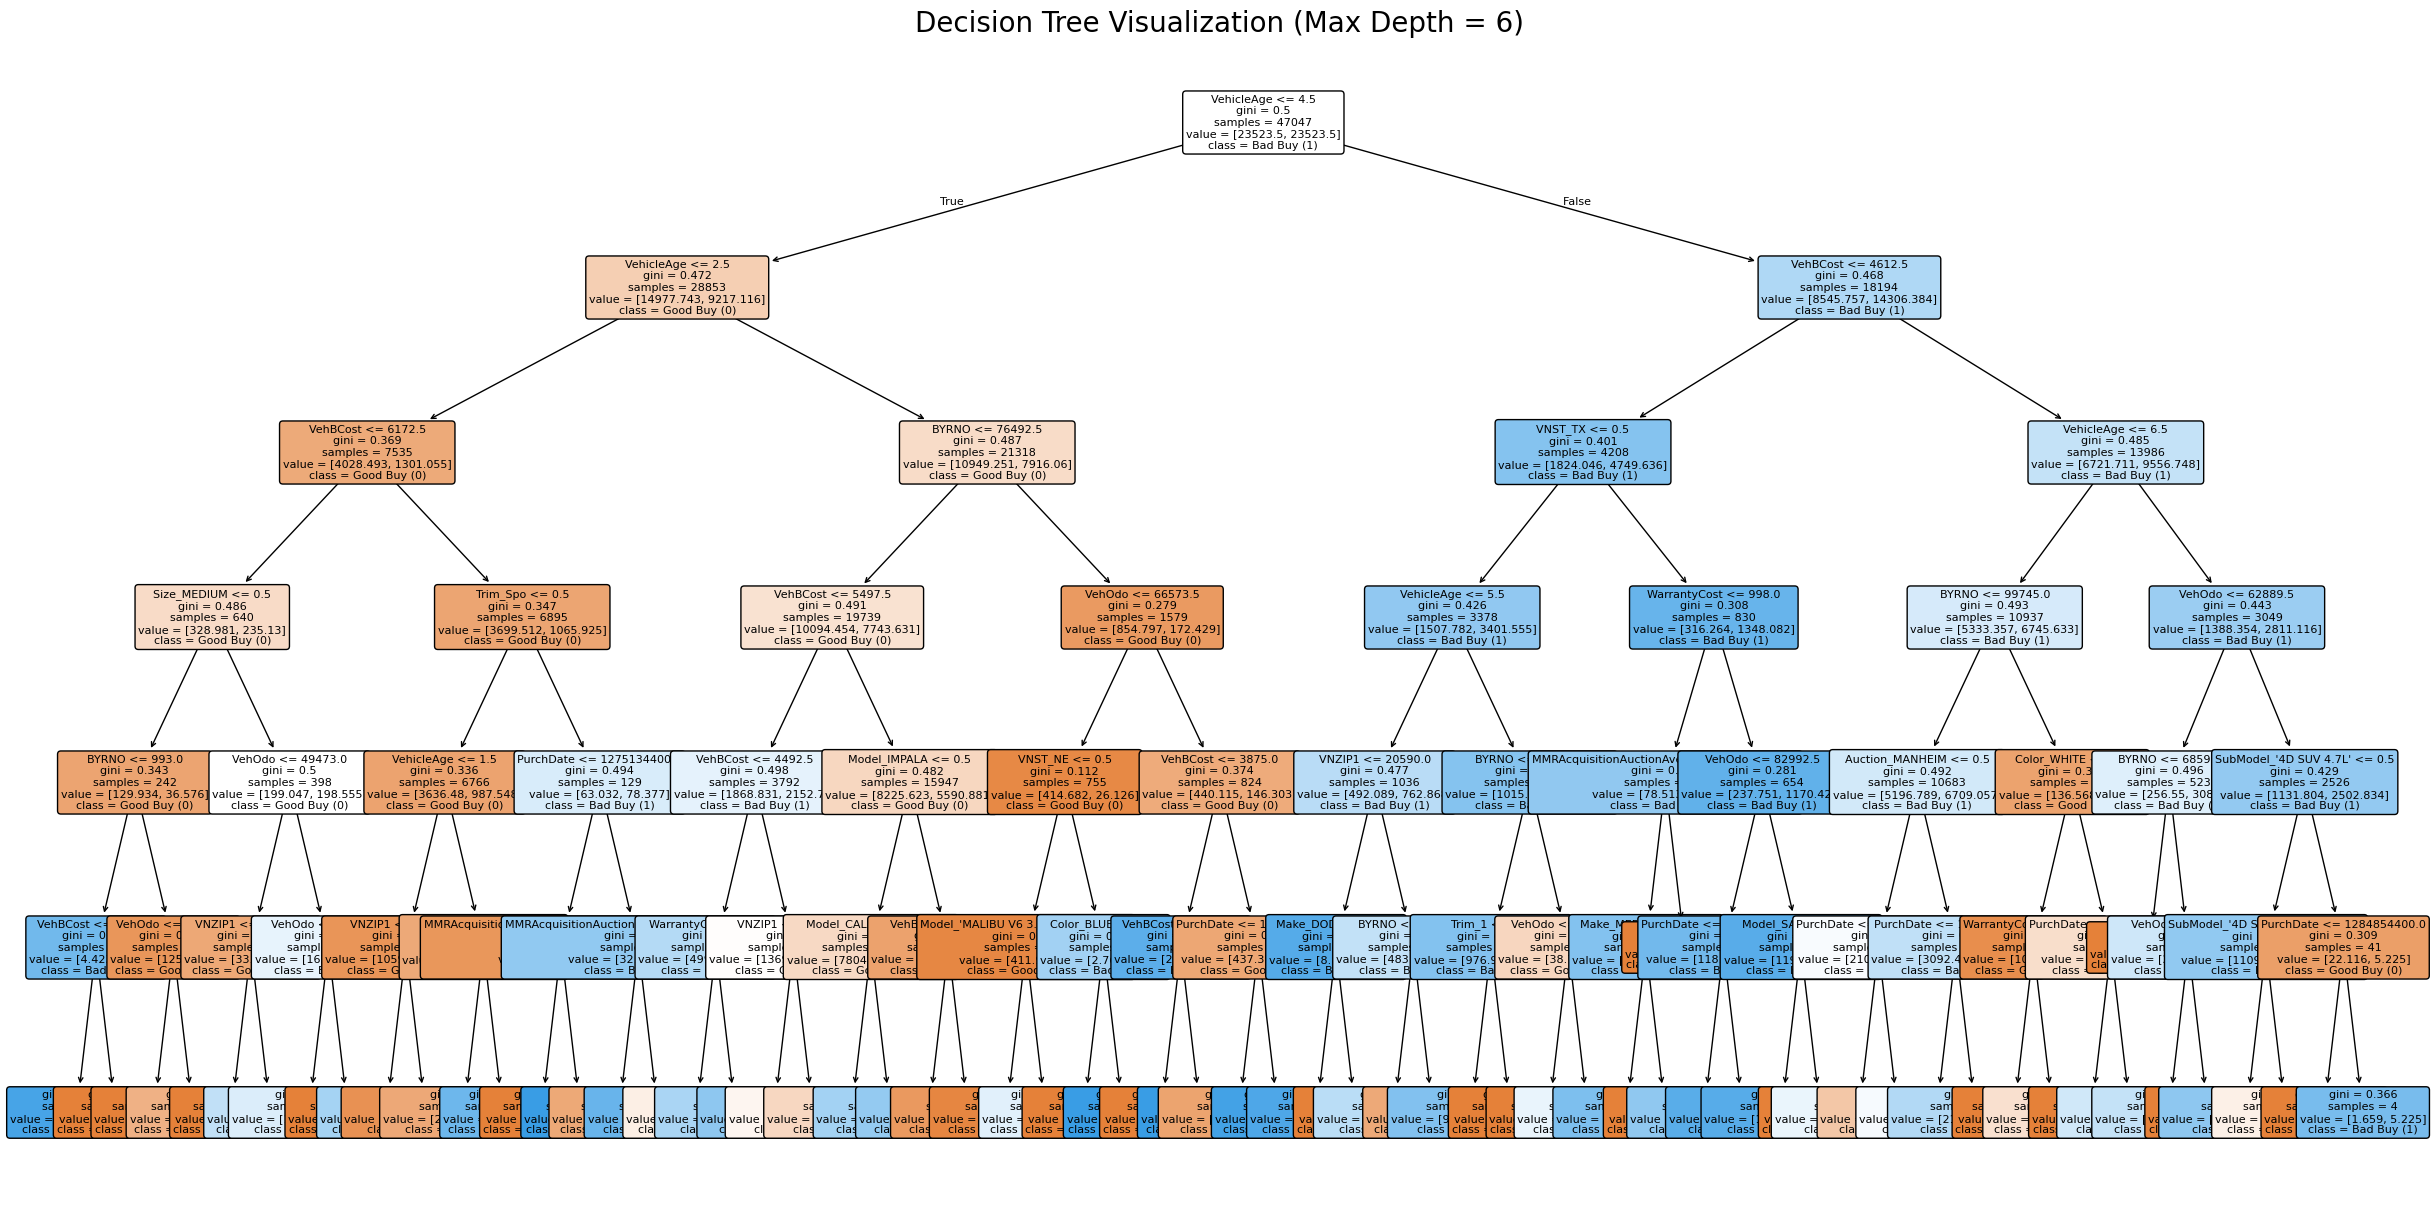

In [ ]:
# Build model with training
dt_model_v6 = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt_model_v6.fit(X_train, y_train)

# Visualize decision tree

plt.figure(figsize=(30, 15))

# Plot the trained Decision Tree
tree.plot_tree(dt_model_v6,
               feature_names=X.columns,
               class_names=['Good Buy (0)', 'Bad Buy (1)'],
               filled=True,      # Colors the boxes based on the majority class
               rounded=True,     # Rounds the corners of the boxes
               fontsize=8)       # A slightly smaller font to fit more nodes


plt.title('Decision Tree Visualization (Max Depth = 6)', fontsize=20)
plt.show()

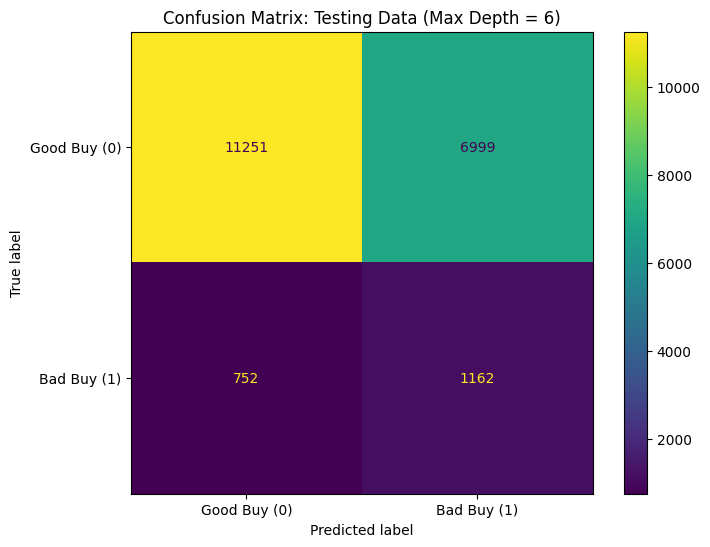

In [ ]:
# Predict on the testing data using the new max_depth=6 model
y_test_pred_v6 = dt_model_v6.predict(X_test)

# 2. Generate the confusion matrix
cm_test_v6 = confusion_matrix(y_test, y_test_pred_v6)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test_v6,
                              display_labels=['Good Buy (0)', 'Bad Buy (1)'])


disp.plot(values_format='d', ax=plt.gca())

plt.title('Confusion Matrix: Testing Data (Max Depth = 6)')
plt.show()

In [ ]:

# Print the classification report for the new model on the testing data
print("\nClassification Report: Testing Data Predictions (Max Depth = 6)\n")
print(classification_report(y_test, y_test_pred_v6, target_names=['Good Buy (0)', 'Bad Buy (1)']))


Classification Report: Testing Data Predictions (Max Depth = 6)

              precision    recall  f1-score   support

Good Buy (0)       0.94      0.62      0.74     18250
 Bad Buy (1)       0.14      0.61      0.23      1914

    accuracy                           0.62     20164
   macro avg       0.54      0.61      0.49     20164
weighted avg       0.86      0.62      0.70     20164



Within the final model, we would achieve a higher accuracy of 62% when using the best max depth of 6.

###5. Evaluation

The original problem we started with is dealerships not being able to determine kicked cars and losing money because of it. Our top performing model with the max depth of 6 would directly address the problem to try and figure out what cars are kicked/ bad buys using patterns to identify them. Though this isn't to say that it is the end all of solutions. <br>

This is due to the data being unbalanced with an accuracy of 62%, which isn't the greatest.

While this model isn't the most practical for business, it's certaintly more helpful to look at rather than just blindly guessing at an auction. With this model, buyers can have a better chance at picking valuable cars through other patterns identified within this report.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Assignment1.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Assignment1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 15 image(s).
[NbConvertApp] Writing 1959214 bytes to /content/drive/MyDrive/Colab Notebooks/Assignment1.html
